In [83]:
from config_path import add_to_sys_path
add_to_sys_path()  # Call the function to add src code to path #TODO: make into a module

import numpy as np
from sympy.physics.wigner import wigner_3j,wigner_6j
import sympy as sy
from IPython.display import Latex
import matplotlib.pyplot as plt
# %matplotlib qt # uncomment this to make plots pop up in windows

# The following three lines are only for asthetics and can be commented out if desired
pretty = True
if pretty:
    import seaborn as sns
    sns.set_theme()
    sns.set_palette('terrain')

from Energy_Levels import MoleculeLevels
np.set_printoptions(precision=5, suppress=True) # Making numpy printing nicer

This notebook computes the energy levels for M-X molecules, M=metal, X=Ligand

The heart of the code is the MoleculeLevels class. This class is initialized using a class method:

In [84]:
X0 = MoleculeLevels.initialize_state(
    molecule_name = 'RaF', 
        # Used to look up constants in central database if params = None
    elec_state = 'X',
        # Electronic state label, e.g. 'X', 'A', etc
    vib_state = 0, 
        # Vibrational state label, can be either integer or '000', '010', etc.
    N_list = [0,1,2,3], 
        # List of rotational states to consider. 
    fermion_or_boson = 'boson', 
        # Is the total F integer or half-integer?
    M_sublevels = 'all', 
        # Options are 'all' (default), 'none' 'pos', or 'custom'. Specifying 'custom' means the input to kwarg M_list is used
    I_nuclei = [0,1/2], 
        # List of nuclear spins in the molecule. Order goes [Metal, Ligand]
    isotope = 226, 
        # Atomic mass, optional but makes plots nicer, functionally just used for backwards compatability for YbOH
    round=8, 
        # Round all numerical values to this many digits
    params = None,
        # If None, use database to look up effective Hamiltonian constants. Otherwise, input a dictionary of constants to override database values.
    P_values = [1/2],
        # List of projection quantum numbers of J (aka Omega) to consider (i.e. [1/2] or [1/2, 3/2] for a Pi_1/2 state)
)

Complete info about initialize_state can be obtained with `help(MoleculeLevels.initialize_state)`

The instance `X0` of the class `MoleculeLevels` carries information about the RaX ground state. We can check out its attributes and see what they return. We see that the effective Hamiltonian parameters are available.

In [85]:
X0.__dict__

{'molecule': 'RaF',
 'spin_statistics': 'boson',
 'electronic_state': 'X',
 'vibrational_state': 0,
 'vibronic_state': 'X0',
 'parameters': {'mu_B': 1.399624494,
  'g_S': 2.0023,
  'g_L': 1,
  '2_e0c': 75346062800.0,
  'mu_N': 0.000762259323,
  'c': 19,
  'Be': 5755.56,
  'Gamma_SR': 175.38,
  'bF': 96.3,
  'muE': 1.96834092,
  'D': 0.004197094412},
 'N_range': [0, 1, 2, 3],
 'M_values': 'all',
 'round': 8,
 'e_spin': 0.5,
 'I_spins': [0, 0.5],
 'M_range': [],
 'P_values': [0.5],
 'trap': False,
 'theta_num': None,
 'metadata': {'isotope': 226},
 'iso_state': '174X000',
 'library': <molecule_library_class.Molecule_Library at 0x14a4e6060>,
 'matrix_elements': {'N^2': functools.partial(<function Rot_bBJ at 0x12e3f8ea0>, I=0.5),
  'N.S': functools.partial(<function SR_bBJ at 0x12e3f8f40>, I=0.5),
  'l-doubling': functools.partial(<function lD_bBJ at 0x12e3f9940>, I=0.5),
  'l doubling p': functools.partial(<function p_lD_bBJ at 0x12e3f9800>, I=0.5),
  'l doubling q': functools.partial(<fu

The Hamiltonian itself is stored in two forms: `self.H_function` and `self.H_symbolic`.

`H_function(E,B)` returns the numeric Hamiltonian in MHz evaluated as at `Ez = E` and `Bz = B`. 

`H_symbolic` returns a semi-numeric Hamiltonian in MHz, where `Ez` and `Bz` remain symbols, and is mostly for visualization and debugging

In [86]:
print(X0.H_function(0,1e-3),'\n')
print('Hamiltonian shape =',X0.H_function(0,1e-3).shape)

[[  -72.225       0.          0.0014  ...     0.          0.
      0.     ]
 [    0.         24.0736      0.      ...     0.          0.
      0.     ]
 [    0.0014      0.         24.075   ...     0.          0.
      0.     ]
 ...
 [    0.          0.          0.      ... 69352.20576     0.
      0.     ]
 [    0.          0.          0.      ...     0.      69352.20611
      0.     ]
 [    0.          0.          0.      ...     0.          0.
  69352.20646]] 

Hamiltonian shape = (64, 64)


In [87]:
X0.H_symbolic

Matrix([
[               -72.225,                            0,    1.4012340621681*B_z,                            0,                      0,                                        0,         0.65611364*E_z,                                        0,                                        0, -0.927884808145978*E_z,                                        0,                                     0,                                      0,                      0,                                      0,                                     0,                                       0,                      0,                                       0,                                        0,                                        0,                      0,                                        0,                                        0,                                        0,                                        0,                      0,                                        0,             

The Hamiltonian is expressed in a default basis depending on the state of interest. For the bosonic `X0` state considered here, the default is Hund's case $b_{\beta J}$. Each basis vector is labeled by a series of quantum numbers, given by the attribute `self.q_str`. Note this does not include quantum numbers that are the same for all of our states, such as $S$ or $I$, which can be queried from the attributes of `X0`.

In [88]:
print("Hund\'s case", X0.hunds_case)
print("Quantum numbers:", X0.q_str)
print("S =", X0.e_spin)
print("[I_Metal, I_Ligand] =", X0.I_spins)

Hund's case bBJ
Quantum numbers: ['K', 'N', 'J', 'F', 'M']
S = 0.5
[I_Metal, I_Ligand] = [0, 0.5]


`self.q_numbers` is a dictionary containing the quantum number values specific to each basis vector. For RaF `X0`, the basis vector is $|\Lambda;N,S,J,I,F,M\rangle$. Each `(key,value)` pair in `self.q_numbers` corresponds to a quantum number in `self.q_str` and the list of the values it takes for each basis vector. 

The `i`th basis vector for hypothetical quantum number $X$ is characterized by the `self.q_numbers['X'][i]`.
We can then iterate through the dictionary to write out the values of a single basis vector.

In [89]:
for q in X0.q_str:
    print(f'{q} =',X0.q_numbers[q])

print()
i=1
print('Basis vector',i)
for q, q_value in X0.q_numbers.items():
    print(q,'=',q_value[i])

i=X0.size-1
print('Basis vector',i)
for q, q_value in X0.q_numbers.items():
    print(q,'=',q_value[i])

K = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
N = [0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]
J = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5]
F = [0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 3.0

We can visualize slices of the Hamiltonian with regular indexing, either in symbolic or numerical form. Note we use functions form the `sympy` package to generate and, in this case, numerically round the symbolic output.

In [90]:
print(X0.H_function(0,0)[:6,:6])
sy.N(X0.H_symbolic[:6,:6],5)

[[  -72.225       0.          0.          0.          0.          0.     ]
 [    0.         24.075       0.          0.          0.          0.     ]
 [    0.          0.         24.075       0.          0.          0.     ]
 [    0.          0.          0.         24.075       0.          0.     ]
 [    0.          0.          0.          0.      11353.46488     0.     ]
 [    0.          0.          0.          0.          0.      11329.80932]]


Matrix([
[   -72.225,                   0,  1.4012*B_z,                   0,           0,                     0],
[         0, 24.075 - 1.4012*B_z,           0,                   0,           0,          -0.65611*E_z],
[1.4012*B_z,                   0,      24.075,                   0, 0.65611*E_z,                     0],
[         0,                   0,           0, 1.4012*B_z + 24.075,           0,                     0],
[         0,                   0, 0.65611*E_z,                   0,     11353.0,                     0],
[         0,        -0.65611*E_z,           0,                   0,           0, 0.46708*B_z + 11330.0]])

When the class is initialized, the Hamiltonian function is generated, and the Hamiltonian is diagonalized at a default value of `Ez = 0`, `Bz = 1e-6`. (The finite magnetic field lifts $M$ degeneracies. If `M_values = 'none'`, then `Bz = 0` is used) 

To diagonalize the matrix at a particular value of $E$ and $B$, use the method `self.eigensystem(E,B)`.

`self.evals0` and `self.evecs0` contain the eigenvalues and eigenvectors associated with the most recent diagonalization using the field values stored in `self.E0` and `self.B0`.

In [91]:
evals, evecs = X0.eigensystem(
    Ez_val = 0, 
        # units are V/cm, required arg
    Bz_val = 1e-6, 
        # units are Gauss, required arg
    order=True,
        # This sorts eigenvalues and eigenvectors in ascending order of energy
    method='torch',
        # Diagonalization backend, options are pytorch's linalg.eigh via 'torch' (default) or numpy's LA.eigh() 'numpy' or scipy's sciLA.eigh via 'scipy'
    Normalize = False,
        # Whether to explicitly normalize eigenvectors. Diagonalization backend should handle this, so default is False.
    angle = None,
        # Default None. Used for AC stark shift calculations only
    chop = None,
        # Default None. Will zero eigenvectors coefficients if their magnitude is smaller than the chop value.
)
    

Once we have eigenvalues and eigenvectors, we can use `self.write_state()` to print the eigenvectors in the the default basis given by `self.q_str`. If no field arguments are provided, the function will use the values from `self.E0` and `self.B0`. 

In [92]:
X0.write_state(
    eval_i = 0, 
        # Index of eigenvector to print
    Ez = None,
    Bz = None,
        # None by default, uses self.evecs0. If field values are provided, the function recomputes the eigensystem with those values
    show_energy = True,
        # Whether or not to print the associated eigenvalue
    show_PTV = False,
        # If true, will also print the expectation value of the P,T violating operator of interest stored in self.H_PTV
)

E = -72.225 MHz

 1.0 |K=0,N=0.0,J=0.5,F=0.0,M=0.0> 

 -1e-08 |K=0,N=0.0,J=0.5,F=1.0,M=0.0> 



For fancy, pretty printing, you can use `self.gen_state_str`. This function can show the state in any basis, see below for further info. 

This function returns a string fromatted for Latex display. For use in plots, just return the string as is. 

For best results in Jupyter notebooks, wrap the output with `display(Latex(...))`, where `Latex` is imported from `IPython.display`.

In [94]:
idx = 0
print(rf'Eigenvector for state index {idx}, evaluated at Ez = {X0.E0} V/cm, Bz = {X0.B0} G, with E = {X0.evals0[idx]} MHz')
state_str_bBJ = X0.gen_state_str(
        vector_idx = idx, # Index of eigenvector  
        evecs=None, # If None, uses self.evecs0
        basis=None, 
            # str, defaults to self.hunds_case. 
            # Options: 'decoupled' (all momenta decoupled), 'aBJ', 'bBJ', 'bBS', 'recouple' (decouple all then recouple J), 'decouple_I' (decouple just I) 
        label_q=None, 
            # List of quantum numbers to include in the label. Default None means include all in self.q_str
        parity=True, 
            # Whether to include +/- parity label, default False
        single=False, 
            # If True, only return the basis vector with the largest coefficient
        thresh=0.01, 
            # Threshold for showing eigenvector coefficients
        show_coeff=True, 
            # Whether to show eigenvector coefficients at all
        new_line=False, 
            # Whether to put each basis vector on a new line
        round=4, 
            # Number of digits to round coefficients to, default None means no rounding
        )
display(Latex(state_str_bBJ))

Eigenvector for state index 0, evaluated at Ez = 0 V/cm, Bz = 1e-06 G, with E = -72.225 MHz


<IPython.core.display.Latex object>

In [95]:
idx = idx

kwargs = dict(
        parity=False, 
        round=4,
        new_line=False)

state_str_aBJ = X0.gen_state_str(
        vector_idx = idx,
        basis='aBJ', 
        label_q=None, 
        **kwargs
        )
state_str_dcpl = X0.gen_state_str(
        vector_idx = idx,
        basis='decoupled', 
        label_q=None, 
        **kwargs
        )
state_str_bBS = X0.gen_state_str(
        vector_idx = idx,
        basis='bBS', 
        label_q=['K','N','G','F','M'], 
        **kwargs
        )
print('Same state in Hund\'s case aBJ basis:')
display(Latex(state_str_aBJ))

print('Same state in fully decoupled basis:')
display(Latex(state_str_dcpl))

print('Same state in Hund\'s case bBS basis:')
display(Latex(state_str_bBS))

Same state in Hund's case aBJ basis:


<IPython.core.display.Latex object>

Same state in fully decoupled basis:


<IPython.core.display.Latex object>

Same state in Hund's case bBS basis:


<IPython.core.display.Latex object>

We can also sort and select eigenvectors by quantum number values using `self.select_q`.

In [96]:
idx_list = X0.select_q(
    q_dict = {'N':1, 'F':2, 'M':[0,1,2]},
        # Dictionary of quantum numbers and their desired values
    evecs = None,  
        # If None, uses self.evecs0
    parity = '-'
        # User can specify '+', '-', or None (default)
)

for i in idx_list:
    print(f'State {i}')
    state_str_bBJ = X0.gen_state_str(i, parity=True,round=4,thresh=0.001)
    state_str_aBJ = X0.gen_state_str(i, parity=True,basis='aBJ',round=4,thresh=0.001)
    display(Latex(state_str_bBJ))
    display(Latex(state_str_aBJ))

State 13


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

State 14


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

State 15


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

If `self.M_values` is not `'none'`, we can also generate Stark and Zeeman shift plots. 

First we initialize the field values to consider.

In [97]:
Bz = np.linspace(1e-8,500,1000)
Ez = np.linspace(0.0,500,1000)

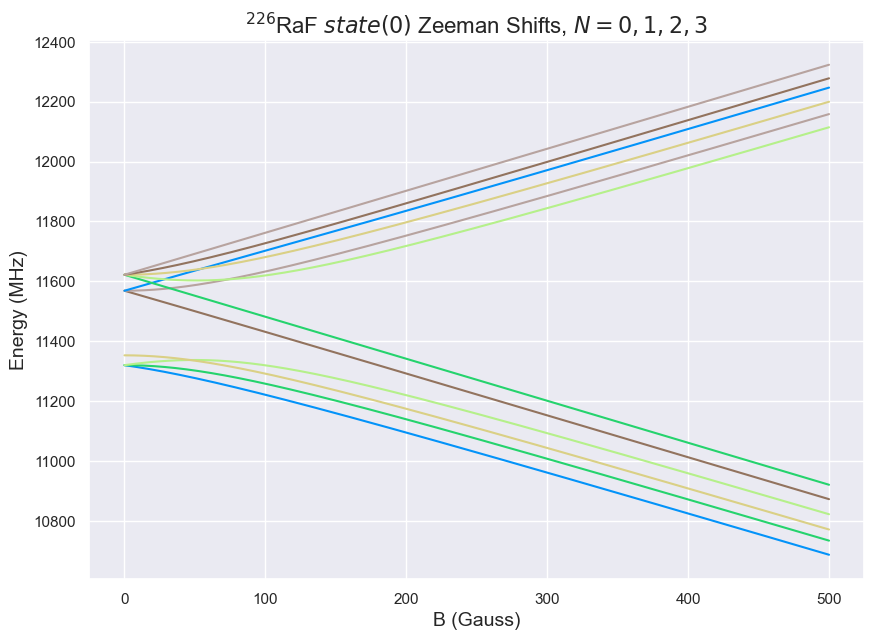

In [98]:
X0.ZeemanMap(
    Bz_array = Bz,
    Ez_val = 0, 
    plot=True,
        # Whether to also output a plot, default False
    output=False,
        # Whether to return the eigenvalue and eigenvectors vs B field, default is False
    write_attribute = True,
        # Whether to write the output arrays to self.evals_B self.evecs_B, default is True
    method = 'torch',
        # Diagonalization backend
    order = True,
        # If True, orders and connects the eigenvectors across B field values using inner products
    idx = X0.select_q({'N':1})
        # List of indices to highlight in the plot (e.g. states of interest)
    )

The field shifts are stored as attributes. This allows us to compute the derivative of the Zeeman shifts, which tells us the magnetization of the levels (i.e. expectation value of magnetic sensitivity)

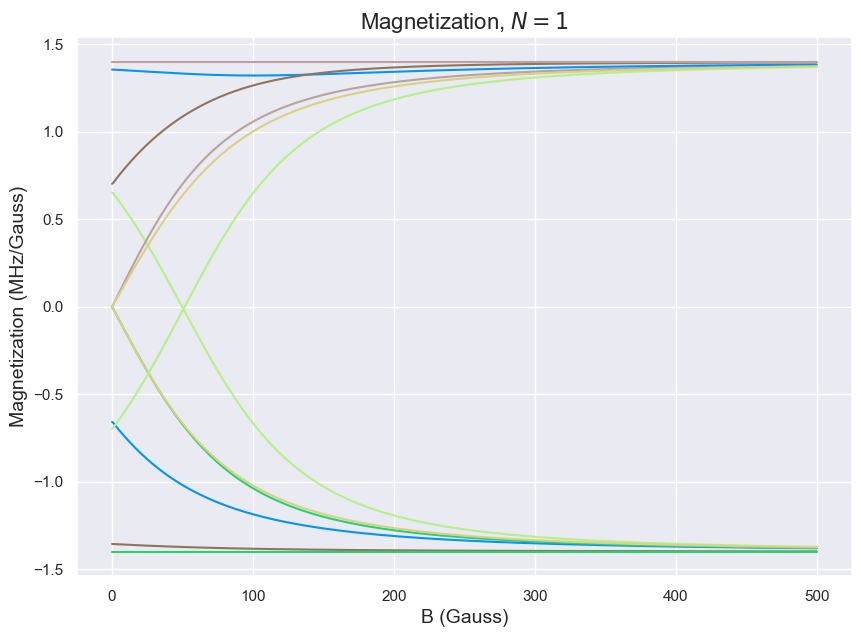

In [100]:
dB = Bz[1] - Bz[0]
plt.figure(figsize=(10,7))
for (i,trace) in enumerate(X0.evals_B.T[X0.select_q({'N':1})]):
    plt.plot(Bz,np.gradient(trace,dB))
plt.xlabel('B (Gauss)',fontsize=14)
plt.ylabel('Magnetization (MHz/Gauss)',fontsize=14)
plt.title(r'Magnetization, $N=1$',fontsize=16);

We can either plot directly with the StarkMap/ZeemanMap function, or we can use plot_evals_EB() to plot with additional options.

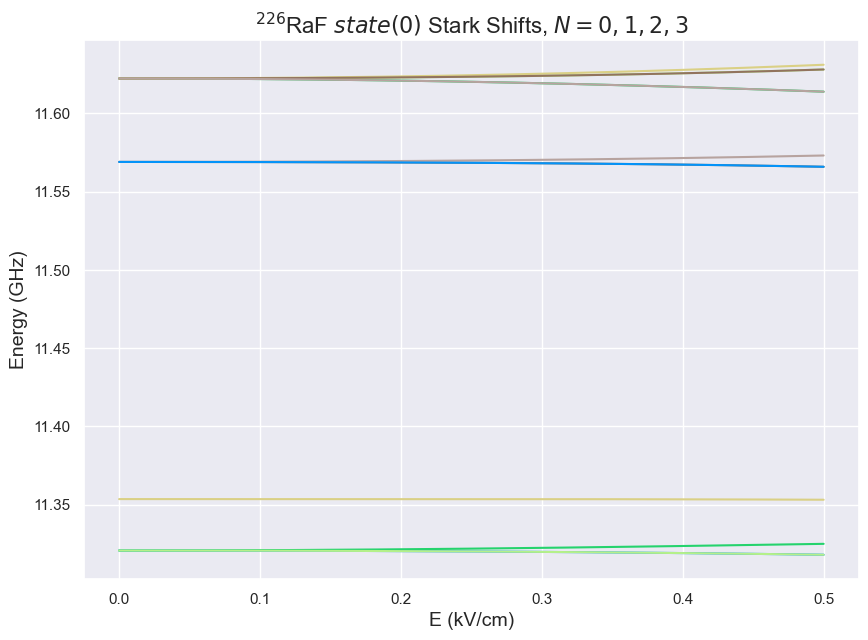

In [101]:
X0.StarkMap(Ez,1e-5,plot=False)
X0.plot_evals_EB('E',kV_kG=True,GHz=True,idx=X0.select_q({'N':1}))

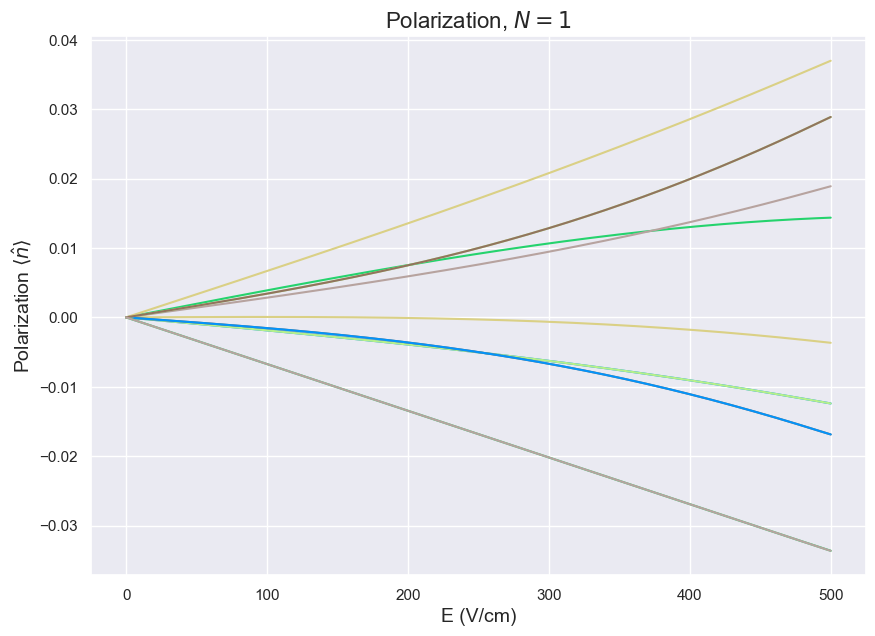

In [102]:
dE = Ez[1] - Ez[0]
plt.figure(figsize=(10,7))
for (i,trace) in enumerate(X0.evals_E.T[X0.select_q({'N':1})]):
    grad = np.gradient(trace,dE)
    plt.plot(Ez,grad)
plt.xlabel('E (V/cm)',fontsize=14)
plt.ylabel(r'Polarization $\langle \hat{n} \rangle$',fontsize=14)
plt.title(r'Polarization, $N=1$',fontsize=16);

We can display a plot of the energy levels at arbitray field. (The code does not handle parity labeling well, so I am leaving out L for zero field.)\
The first and second argument are the E and B field values. The third argument is the pattern forming quantum number that sets how often the levels are labeled.

In [23]:
help(X0.display_levels)

Help on method display_levels in module Energy_Levels:

display_levels(Ez, Bz, pattern_q, idx=None, label=True, label_off=0.03, parity=False, pretty=True, thickness=1.5, label_q=None, width=0.75, ket_size=10, label_size=14, figsize=(10, 10), ylim=None, deltaE_label=3000, alt_label=False) method of Energy_Levels.MoleculeLevels instance



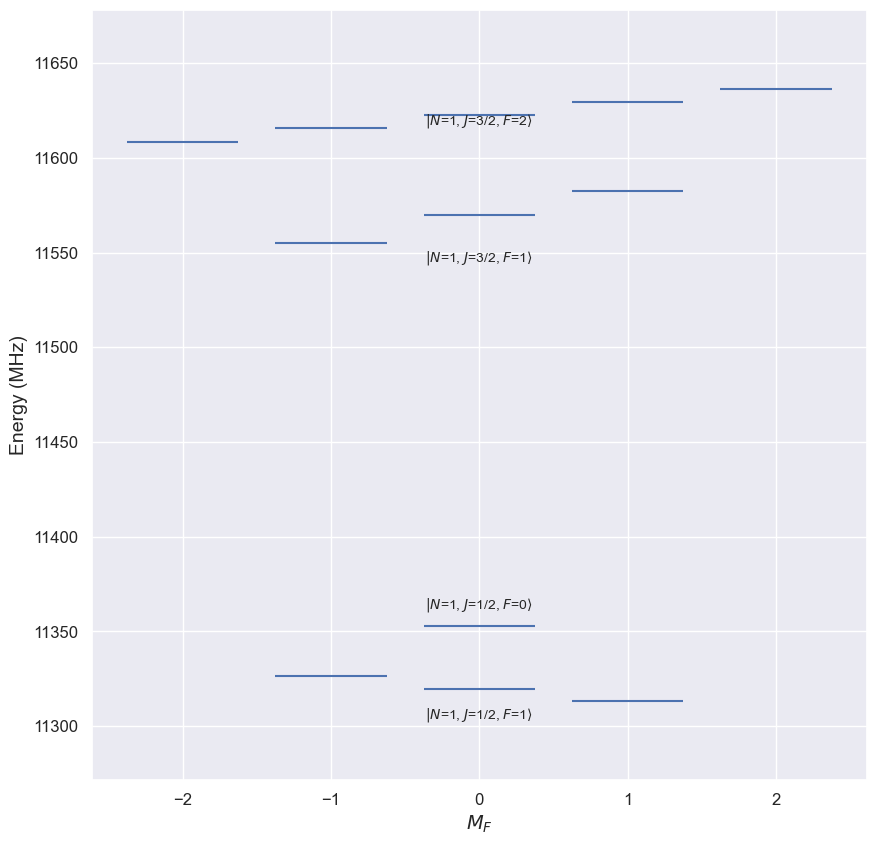

In [105]:
X0.display_levels(0,10,'F',idx = X0.select_q({'N':1}),label_q=[q for q in X0.q_str if q!='K'],alt_label=True);

Additionally we can look at g-factors and dipole moments at a given E, B field

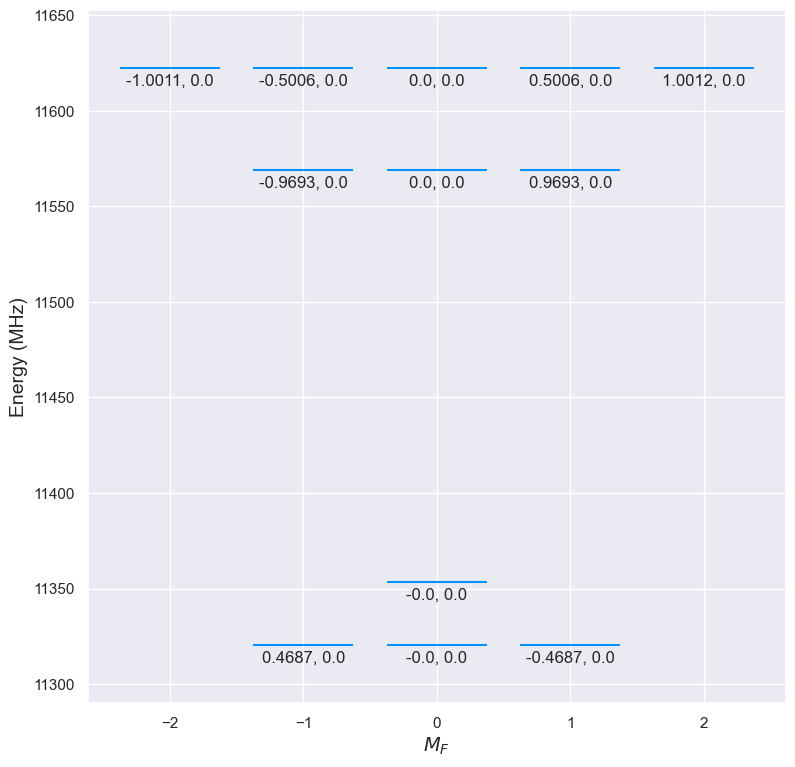

In [26]:
X0.display_g_D_eff(100,1e-3,Estep=1e-1,Bstep=1e-3,round=4);

We can also look at PT violating shifts. Here, we consider the EDM shifts as a function of E field.

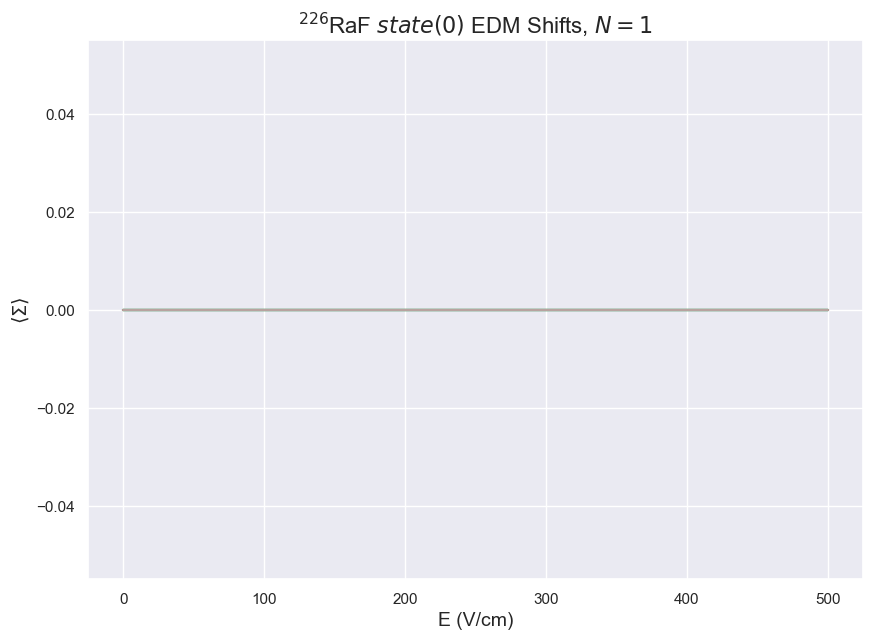

In [27]:
X0.PTV_Map('EDM',E_or_B='E',plot=True)

The values are stored in the attrbiute PTV_E or PTV_B, depending on what x-axis was used. To obtain the PTV shift for a single level as a function of field, look at the transpose of PTV_E.

You can also display the PTV shifts for all levels in a given field configuration. Once again the first argument is E and the second is B

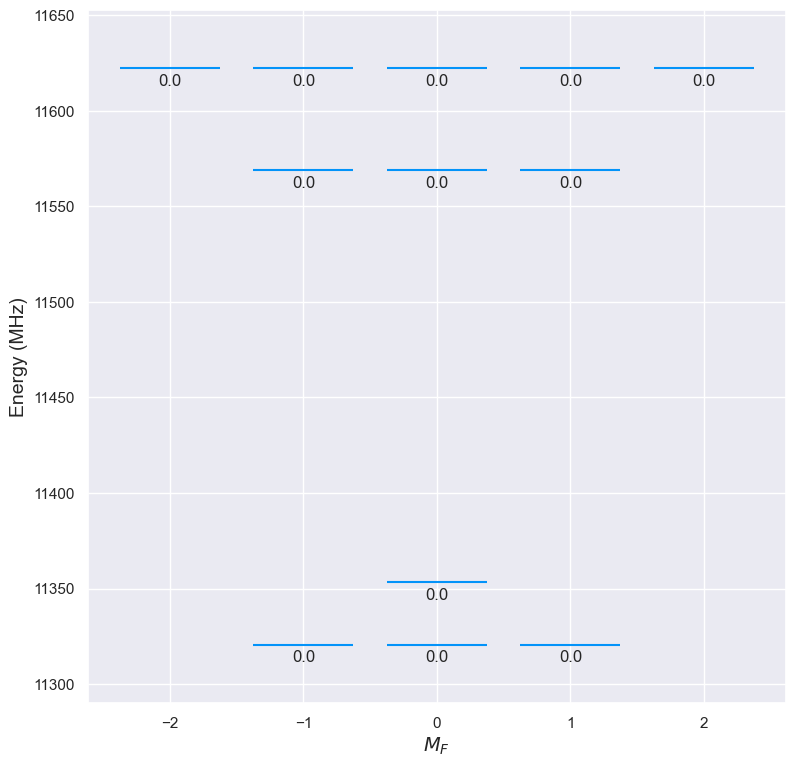

In [28]:
X0.display_PTV(145,1e-6,'EDM')

You can also look at g_factors as a function of E or B field. Note these functions require StarkMap and ZeemanMap to be run previously. If step is too small, the data will be noisy.

In [29]:
X0.g_eff_Map('E',step=1e-3);

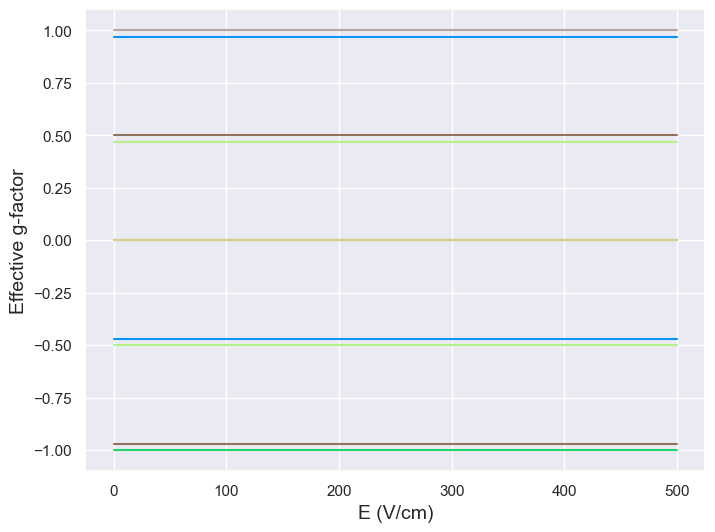

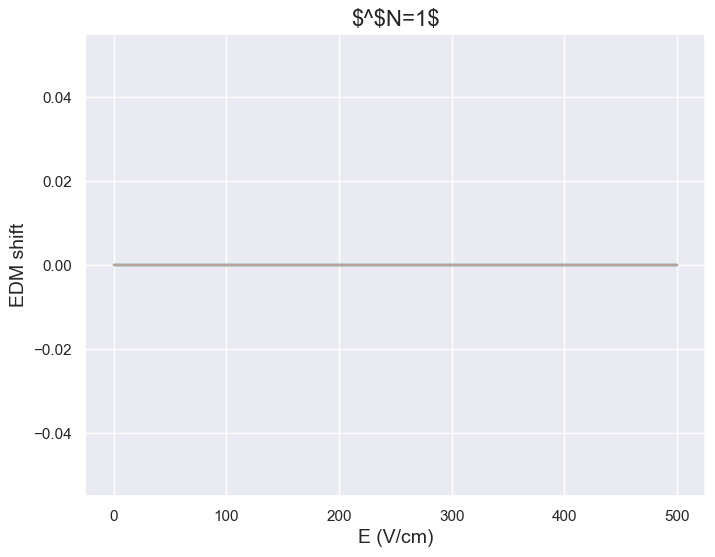

In [30]:
j = range(len(X0.evals0))
plt.figure(figsize=(8,6))
for i in j:#range(len(X010_174.g_eff_E.T)):
    plt.plot(Ez,X0.g_eff_E.T[i])
plt.xlabel('E (V/cm)',fontsize=14)
plt.ylabel('Effective g-factor',fontsize=14)
plt.title(r'',fontsize=16);
plt.figure(figsize=(8,6))
for i in j:#range(len(X010_174.PTV_E.T)):
    plt.plot(Ez,X0.PTV_E.T[i])
plt.xlabel('E (V/cm)',fontsize=14)
plt.ylabel('EDM shift',fontsize=14)
plt.title(r'$^$N=1$',fontsize=16);